**House Price Prediction**

The objective of this task is to predict house prices using property features such as
square footage and number of bedrooms. This helps understand regression modeling
using real-world data.


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Import Libraries
Pandas is used for handling datasets, NumPy is used for numerical operations,
and Matplotlib is used for visualization.


In [19]:
import pandas as pd

df = pd.read_csv("/content/House Price Prediction Dataset.csv")  # always use /content/ path
df.head()  # display first 5 rows


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


### Load Dataset
The dataset is loaded using pandas. It contains house features and their corresponding prices.


In [20]:
df.head()


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


### Dataset Preview
This shows the first few rows of the dataset to understand the structure and values.


In [21]:
df.isnull().sum()


,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


### Missing Values Check
This step checks whether the dataset contains any missing values.


In [22]:
df.dropna(inplace=True)


### Data Cleaning
Rows with missing values are removed to ensure accurate model training.


In [24]:
# Select relevant features for prediction
X = df[['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Garage']]  # input features
y = df['Price']  # target variable


### Features and Target
- **Features (X):** Area, Bedrooms, Bathrooms, Floors, Garage  
- **Target (y):** Price  
These features are most likely to influence house prices.


In [25]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### Train-Test Split
We split the dataset into:
- 80% for training the model
- 20% for testing the model's predictions
This helps evaluate how well the model generalizes.


In [27]:
X.dtypes


,0
Area,int64
Bedrooms,int64
Bathrooms,int64
Floors,int64
Garage,object


In [28]:
# Convert 'Garage' Yes/No to 1/0
X['Garage'] = X['Garage'].map({'Yes': 1, 'No': 0})


/tmp/ipython-input-1702688347.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Garage'] = X['Garage'].map({'Yes': 1, 'No': 0})


In [29]:
X.dtypes


,0
Area,int64
Bedrooms,int64
Bathrooms,int64
Floors,int64
Garage,int64


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

### Model Training
A Linear Regression model is trained to learn the relationship between selected features and house prices.


In [31]:
# Predict prices on the test set
y_pred = model.predict(X_test)


### Price Prediction
Using the trained model, we predict house prices for the test data.


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)


Mean Absolute Error (MAE): 244425.5903746339
Root Mean Squared Error (RMSE): 280564.34190460533


### Model Evaluation
- **MAE:** average difference between actual and predicted prices  
- **RMSE:** square root of the average squared difference  
Lower values indicate better predictions.


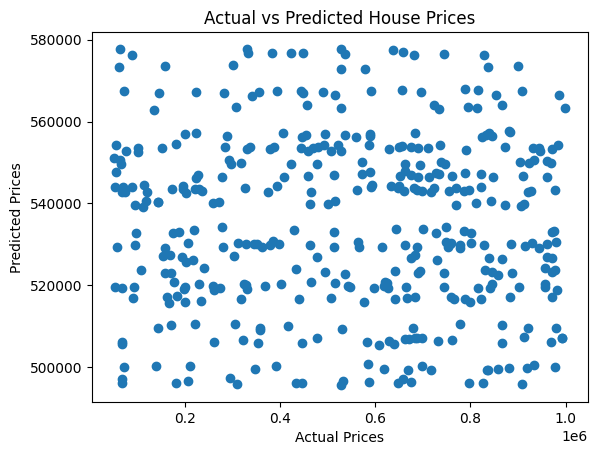

In [33]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()


### Visualization
Scatter plot comparing actual vs predicted prices.  
Points close to the diagonal line indicate accurate predictions.


### Conclusion

- The Linear Regression model predicts house prices based on features like Area, Bedrooms, Bathrooms, Floors, and Garage.
- Evaluation metrics:
  - Mean Absolute Error (MAE): 244,425
  - Root Mean Squared Error (RMSE): 280,564
- The scatter plot shows that most predictions are close to the actual prices.
- The model can be improved by including more features (like YearBuilt, Location, Condition) or using advanced algorithms such as Random Forest or Gradient Boosting.
